# Setting Tasks

# Task 1
[ 2, 7, 25, 14, 14, 21, 20, 6, 13, 3, 23, 14, 1, 8, 1, 8, 16, 21, 2, 17,
7, 5, 20, 17, 18, 10]

Response format: 
Programming code in jupyter notebook/colab/etc. containing the following:  
1)  Generating list of 26 random values, 
2)  Function that calculates the depth of deepest lake 
3)  Result of calculation for provided sample of 26 integers 
4)  Visualization  

# works

In [1]:
 # %pip install matplotlib

In [2]:
import matplotlib.pyplot as plt
import random
import numpy as np

# Generate random array of 26 values
rnd_data = [random.randint(1, 25) for _ in range(26)]
print("Generated data:", rnd_data)

# Task data

example_data = [ 2, 7, 25, 14, 14, # 0-4
                21, 20, 6, 13, 3,
                23, 14, 1, 8, 1,
                8, 16, 21, 2, 17,
                7, 5, 20, 17, 18, 10] # 25 elements, index 0 to 24


def select_subregion(arr, start_idx, end_idx):
    return arr[start_idx:end_idx]

# def calculate_trapped_water(arr):
#     if len(arr) < 3:
#         return 0
    
#     trapped = 0
#     for i in range(1, len(arr) - 1):
#         left_max = max(arr[:i+1])
#         right_max = max(arr[i:])
#         water_level = min(left_max, right_max)
#         trapped += max(0, water_level - arr[i])
    
#     return trapped

def calculate_water_level(arr):
    if len(arr) < 3:
        return 0
    
    left_wall = np.maximum.accumulate(arr)
    right_wall = np.maximum.accumulate(arr[::-1])[::-1] 
    water_level = np.minimum(left_wall, right_wall) - arr

    return water_level

def visualize_with_highlights(arr, start_idx=None, end_idx=None, highest_idxs=None):
    x = list(range(len(arr)))
    terrain = arr

    plt.figure(figsize=(12, 5))
    plt.plot(x, arr, marker="o", label="Heights")
    
    if start_idx is not None and end_idx is not None:
        sub_x = list(range(start_idx, end_idx))
        sub_y = arr[start_idx:end_idx]
        # plt.fill_between(sub_x, sub_y, alpha=0.3, label="Subregion")
        plt.fill_between(sub_x, terrain[start_idx:end_idx], terrain[highest_idxs[1]], color='skyblue', alpha=0.4, label="Subregion")
    
    if highest_idxs:
        for idx in highest_idxs:
            plt.scatter(idx, arr[idx], s=100, color="red", zorder=5, label="Wall Highest" if idx == highest_idxs[0] else "")
    
    plt.title("Trapping Rain Water")
    plt.xlabel("Index")
    plt.ylabel("Height")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# idx1, idx2 = find_two_highest_points(example_data)


Generated data: [12, 25, 21, 19, 14, 20, 21, 16, 10, 9, 1, 6, 3, 23, 15, 11, 16, 17, 15, 4, 24, 13, 22, 16, 16, 10]


# answer data const

Const data: [2, 7, 25, 14, 14, 21, 20, 6, 13, 3, 23, 14, 1, 8, 1, 8, 16, 21, 2, 17, 7, 5, 20, 17, 18, 10]
depth of the deepest lake
20
count of the deepest lake
3
index of deapest lake
[9, 12, 14]


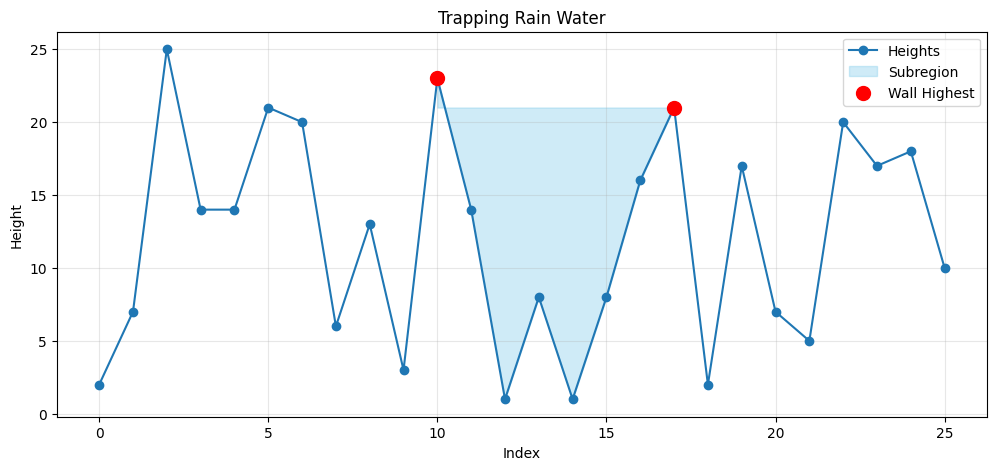

In [3]:
print("Const data:", example_data)
deaph = max(calculate_water_level(example_data))
count_deaph = list(calculate_water_level(example_data)).count(deaph)
indexes = [i for i, x in enumerate(calculate_water_level(example_data)) if x == deaph]

print("depth of the deepest lake", deaph, "count of the deepest lake", count_deaph, "index of deapest lake", indexes,  sep="\n")
idx1, idx2 = 10, 17
visualize_with_highlights(example_data, start_idx=10, end_idx=18, highest_idxs=[idx1, idx2])
# visualize_deaphs(example_data)


# answer random data

Generated data: [12, 25, 21, 19, 14, 20, 21, 16, 10, 9, 1, 6, 3, 23, 15, 11, 16, 17, 15, 4, 24, 13, 22, 16, 16, 10]
depth of the deepest lake
23
count of the deepest lake
1
index of deapest lake
[10]


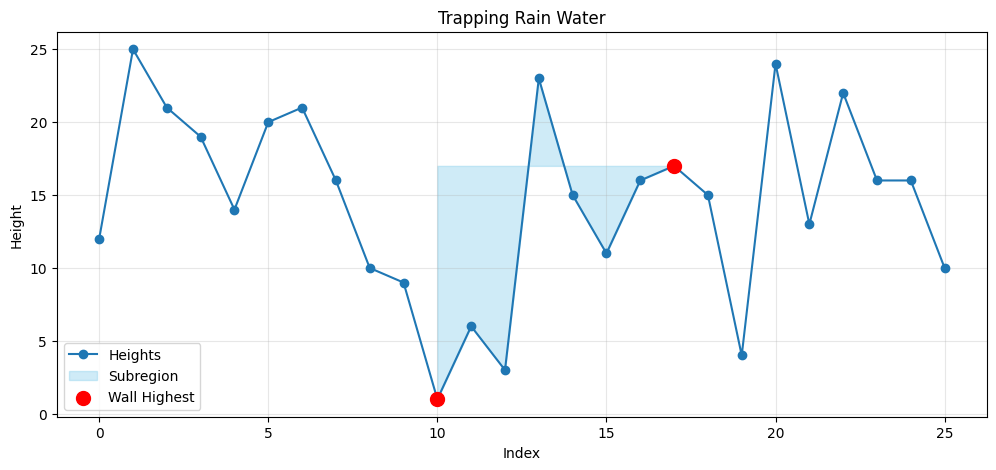

In [4]:
print("Generated data:", rnd_data)

deaph = max(calculate_water_level(rnd_data))
count_deaph = list(calculate_water_level(rnd_data)).count(deaph)
indexes = [i for i, x in enumerate(calculate_water_level(rnd_data)) if x == deaph]

print("depth of the deepest lake", deaph, "count of the deepest lake", count_deaph, "index of deapest lake", indexes,  sep="\n")
idx1, idx2 = 10, 17
visualize_with_highlights(rnd_data, start_idx=10, end_idx=18, highest_idxs=[idx1, idx2])

# work

Index | Height | Left Max | Right Max | Water
--------------------------------------------------
    0 |      2 |        2 |        25 |     0
    1 |      7 |        7 |        25 |     0
    2 |     25 |       25 |        25 |     0
    3 |     14 |       25 |        23 |     9
    4 |     14 |       25 |        23 |     9
    5 |     21 |       25 |        23 |     2
    6 |     20 |       25 |        23 |     3
    7 |      6 |       25 |        23 |    17
    8 |     13 |       25 |        23 |    10
    9 |      3 |       25 |        23 |    20
   10 |     23 |       25 |        23 |     0
   11 |     14 |       25 |        21 |     7
   12 |      1 |       25 |        21 |    20
   13 |      8 |       25 |        21 |    13
   14 |      1 |       25 |        21 |    20
   15 |      8 |       25 |        21 |    13
   16 |     16 |       25 |        21 |     5
   17 |     21 |       25 |        21 |     0
   18 |      2 |       25 |        20 |    18
   19 |     17 |       25 |  

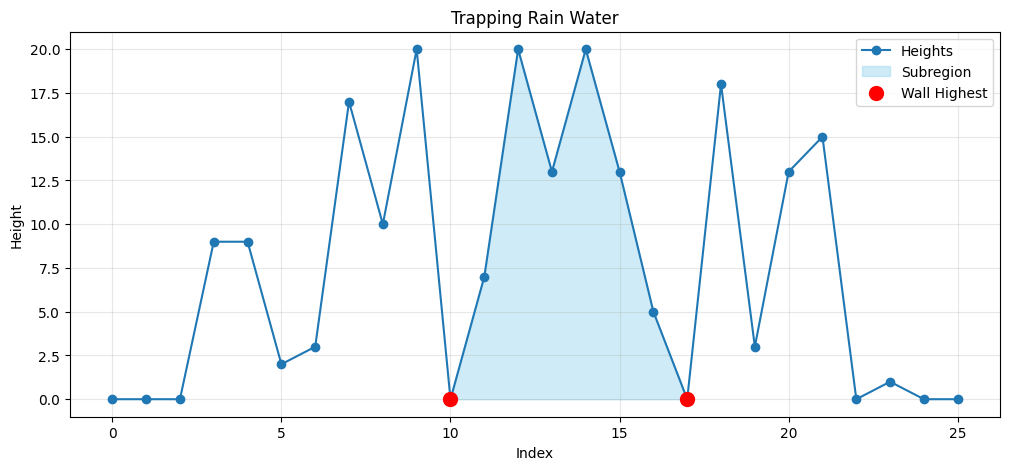

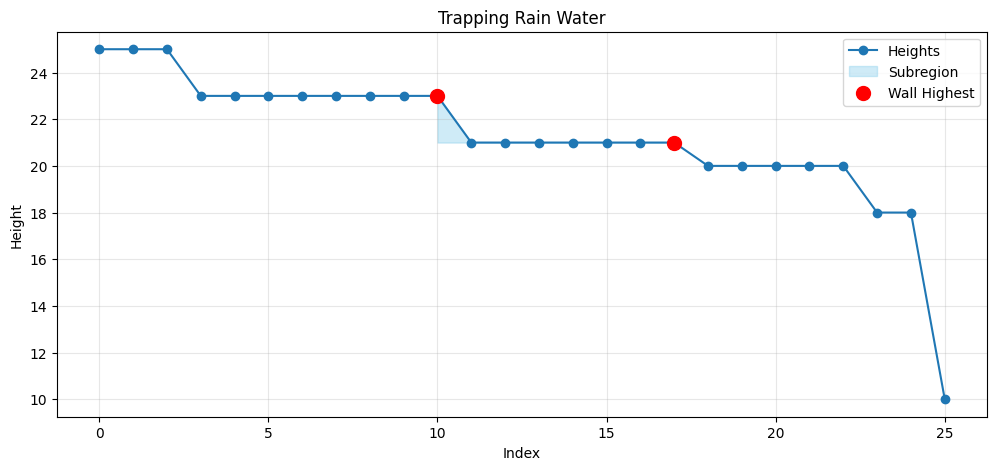

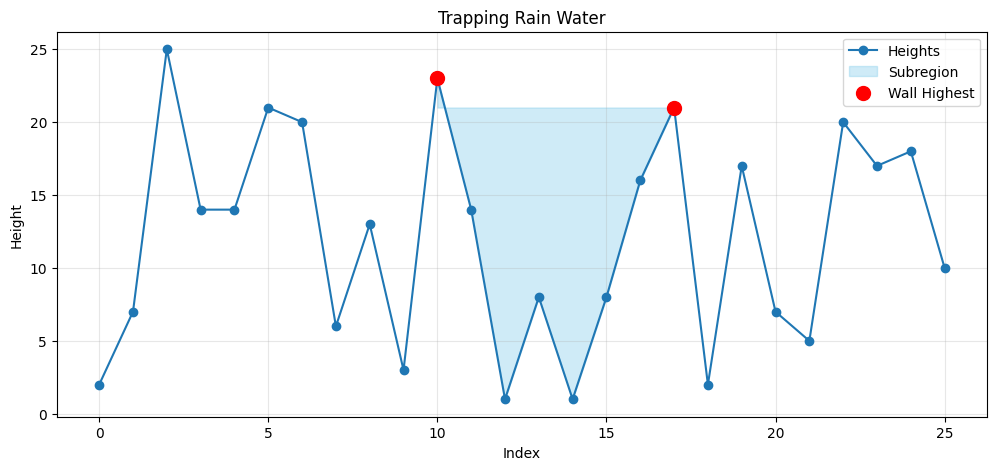

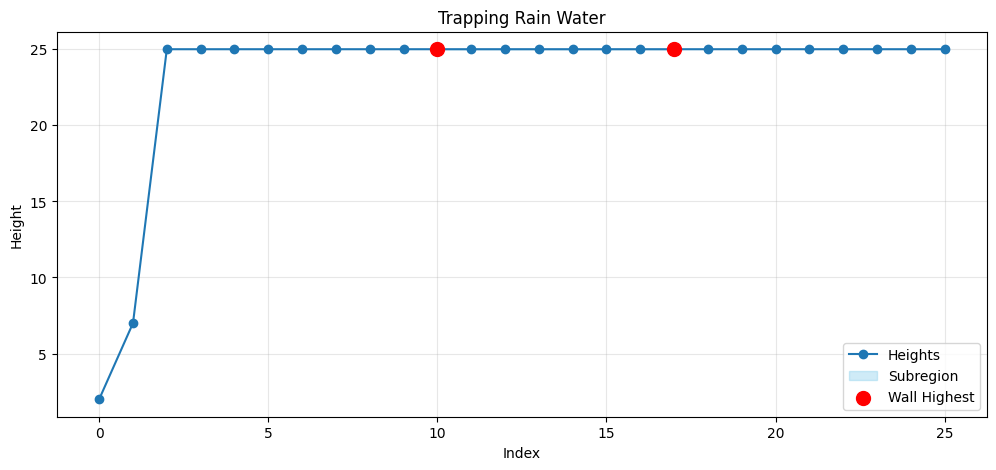

In [5]:
def calculate_water_level(arr):
    if len(arr) < 3:
        return 0
    
    left_wall = np.maximum.accumulate(arr)
    right_wall = np.maximum.accumulate(arr[::-1])[::-1] 
    water_level = np.minimum(left_wall, right_wall) - arr

    return water_level

water_level = calculate_water_level(example_data)
left_wall = np.maximum.accumulate(example_data)
right_wall = np.maximum.accumulate(example_data[::-1])[::-1] 

# Table format output
print("Index | Height | Left Max | Right Max | Water")
print("-" * 50)
for i in range(len(example_data)):
    print(f"{i:5} | {example_data[i]:6} | {left_wall[i]:8} | {right_wall[i]:9} | {water_level[i]:5}")
visualize_with_highlights(water_level, start_idx=10, end_idx=18, highest_idxs=[10, 17])
visualize_with_highlights(right_wall, start_idx=10, end_idx=18, highest_idxs=[10, 17])
visualize_with_highlights(example_data, start_idx=10, end_idx=18, highest_idxs=[10, 17])
visualize_with_highlights(left_wall, start_idx=10, end_idx=18, highest_idxs=[10, 17])